In [10]:
import pandas as pd

df = pd.read_csv("World Weather Repository/GlobalWeatherRepository.csv")

print(df.head())
print(df.shape)
print(df.columns.tolist())

       country     location_name  latitude  longitude        timezone  \
0  Afghanistan             Kabul     34.52      69.18      Asia/Kabul   
1      Albania            Tirana     41.33      19.82   Europe/Tirane   
2      Algeria           Algiers     36.76       3.05  Africa/Algiers   
3      Andorra  Andorra La Vella     42.50       1.52  Europe/Andorra   
4       Angola            Luanda     -8.84      13.23   Africa/Luanda   

   last_updated_epoch      last_updated  temperature_celsius  \
0          1715849100  2024-05-16 13:15                 26.6   
1          1715849100  2024-05-16 10:45                 19.0   
2          1715849100  2024-05-16 09:45                 23.0   
3          1715849100  2024-05-16 10:45                  6.3   
4          1715849100  2024-05-16 09:45                 26.0   

   temperature_fahrenheit condition_text  ...  air_quality_PM2.5  \
0                    79.8  Partly Cloudy  ...                8.4   
1                    66.2  Partly cloudy

In [11]:
missing_values = df.isnull().sum()

missing_df = missing_values[missing_values > 0].sort_values(ascending=False)

print(missing_df)

Series([], dtype: int64)


In [12]:
print(df.dtypes)

country                          object
location_name                    object
latitude                        float64
longitude                       float64
timezone                         object
last_updated_epoch                int64
last_updated                     object
temperature_celsius             float64
temperature_fahrenheit          float64
condition_text                   object
wind_mph                        float64
wind_kph                        float64
wind_degree                       int64
wind_direction                   object
pressure_mb                     float64
pressure_in                     float64
precip_mm                       float64
precip_in                       float64
humidity                          int64
cloud                             int64
feels_like_celsius              float64
feels_like_fahrenheit           float64
visibility_km                   float64
visibility_miles                float64
uv_index                        float64


In [13]:
print(df.describe())

            latitude      longitude  last_updated_epoch  temperature_celsius  \
count  145017.000000  145017.000000        1.450170e+05        145017.000000   
mean       19.221413      21.924111        1.748124e+09            21.260443   
std        24.410826      65.780274        1.863013e+07             9.598162   
min       -41.300000    -175.200000        1.715849e+09           -29.800000   
25%         4.050300      -6.836100        1.732007e+09            15.700000   
50%        17.250000      23.236100        1.748162e+09            23.700000   
75%        40.400000      49.882200        1.764228e+09            27.900000   
max        64.150000     179.220000        1.780381e+09            79.300000   

       temperature_fahrenheit       wind_mph       wind_kph    wind_degree  \
count           145017.000000  145017.000000  145017.000000  145017.000000   
mean                70.270570       7.972278      12.833903     169.080073   
std                 17.276578       7.091831 

In [14]:
duplicates = df.duplicated().sum()
print("Duplicate rows:", duplicates)

Duplicate rows: 0


In [15]:
df['last_updated'] = pd.to_datetime(df['last_updated'])

print(df['last_updated'].head())

0   2024-05-16 13:15:00
1   2024-05-16 10:45:00
2   2024-05-16 09:45:00
3   2024-05-16 10:45:00
4   2024-05-16 09:45:00
Name: last_updated, dtype: datetime64[ns]


In [16]:
import numpy as np

# Replace impossible placeholder values
df.replace(-9999, np.nan, inplace=True)

# Wind speed sanity filtering
df.loc[df['wind_kph'] > 300, 'wind_kph'] = np.nan
df.loc[df['wind_mph'] > 200, 'wind_mph'] = np.nan

# Pressure sanity filtering
df.loc[df['pressure_mb'] > 1100, 'pressure_mb'] = np.nan
df.loc[df['pressure_mb'] < 850, 'pressure_mb'] = np.nan

# PM10 sanity filtering
df.loc[df['air_quality_PM10'] < 0, 'air_quality_PM10'] = np.nan

print(df.isnull().sum().sort_values(ascending=False).head(20))

pressure_mb                     2
air_quality_PM10                2
wind_kph                        1
air_quality_Carbon_Monoxide     1
wind_mph                        1
air_quality_Sulphur_dioxide     1
air_quality_PM2.5               0
uv_index                        0
gust_mph                        0
gust_kph                        0
air_quality_Ozone               0
air_quality_Nitrogen_dioxide    0
country                         0
visibility_km                   0
air_quality_us-epa-index        0
air_quality_gb-defra-index      0
sunrise                         0
sunset                          0
moonrise                        0
moonset                         0
dtype: int64


In [17]:
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns] = df[numeric_columns].fillna(
    df[numeric_columns].median()
)

print(df.isnull().sum().sum())

0


In [18]:
features = [
    'humidity',
    'pressure_mb',
    'precip_mm',
    'cloud',
    'visibility_km',
    'uv_index',
    'wind_kph',
    'gust_kph',
    'air_quality_PM2.5',
    'air_quality_PM10'
]

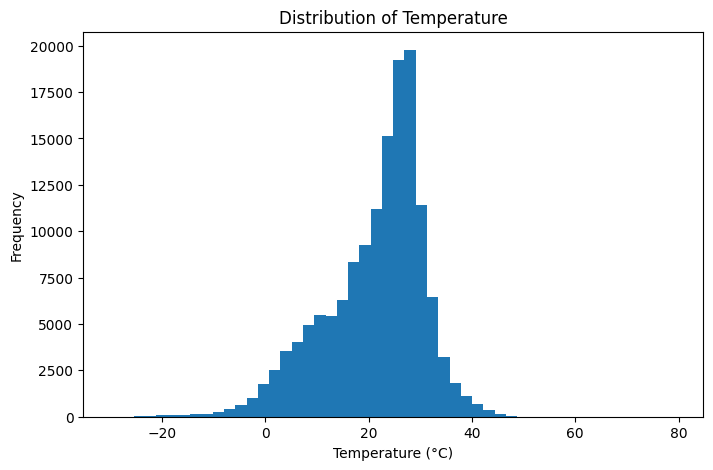

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hist(df['temperature_celsius'], bins=50)
plt.xlabel('Temperature (°C)')
plt.ylabel('Frequency')
plt.title('Distribution of Temperature')
plt.show()


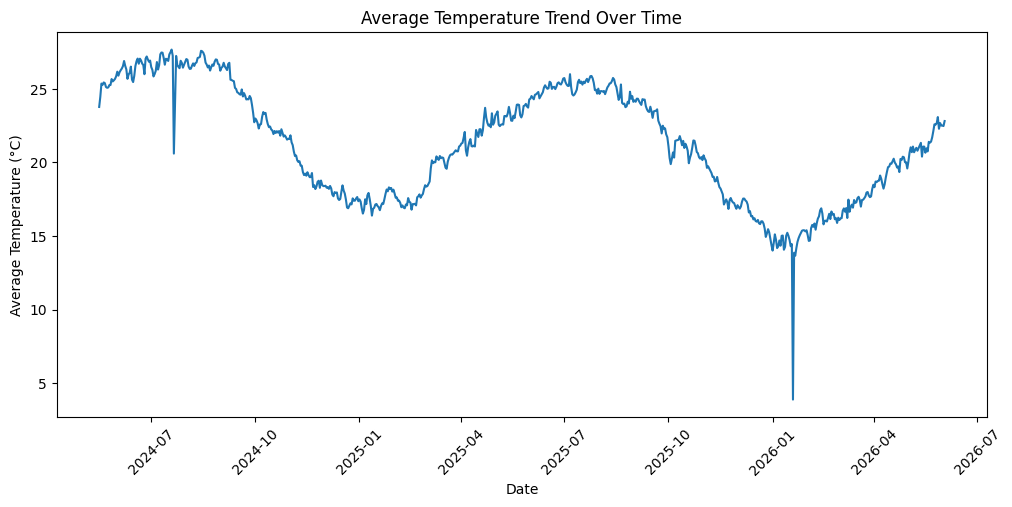

In [20]:
daily_temp = df.groupby(
    df['last_updated'].dt.date
)['temperature_celsius'].mean()

plt.figure(figsize=(12,5))
plt.plot(daily_temp)
plt.xlabel('Date')
plt.ylabel('Average Temperature (°C)')
plt.title('Average Temperature Trend Over Time')
plt.xticks(rotation=45)
plt.show()

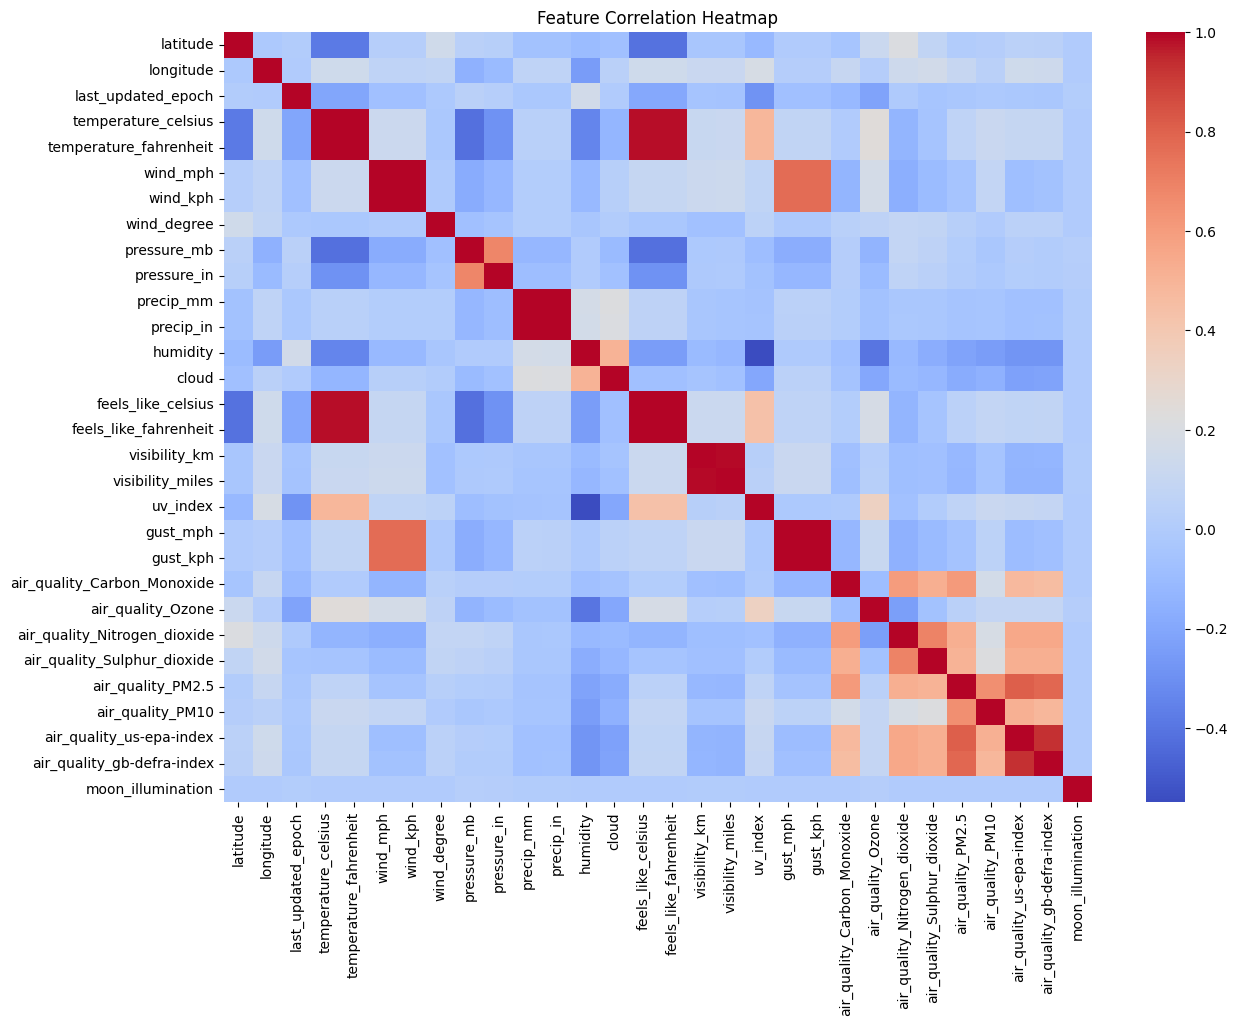

In [22]:
import seaborn as sns

numeric_df = df.select_dtypes(include='number')

plt.figure(figsize=(14,10))
sns.heatmap(
    numeric_df.corr(),
    cmap='coolwarm',
    annot=False
)

plt.title('Feature Correlation Heatmap')
plt.show()

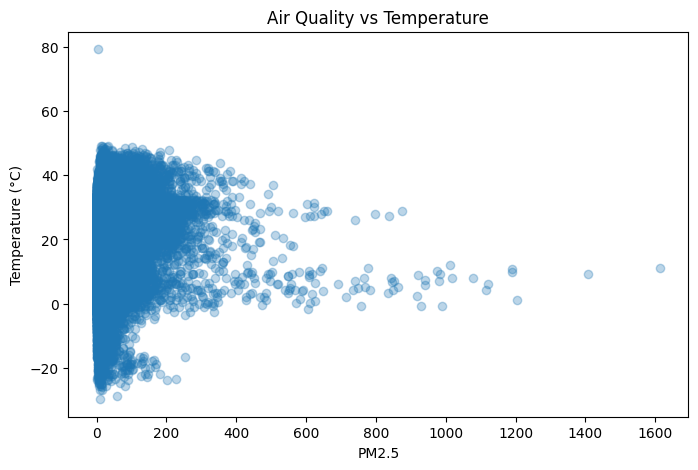

In [23]:
plt.figure(figsize=(8,5))
plt.scatter(
    df['air_quality_PM2.5'],
    df['temperature_celsius'],
    alpha=0.3
)

plt.xlabel('PM2.5')
plt.ylabel('Temperature (°C)')
plt.title('Air Quality vs Temperature')
plt.show()


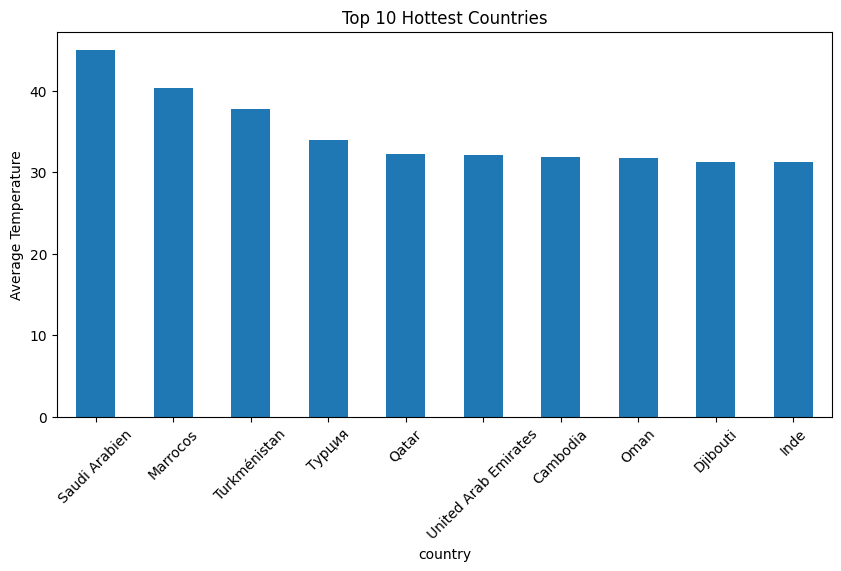

In [24]:
top_hot = df.groupby(
    'country'
)['temperature_celsius'].mean().sort_values(
    ascending=False
).head(10)

plt.figure(figsize=(10,5))
top_hot.plot(kind='bar')
plt.ylabel('Average Temperature')
plt.title('Top 10 Hottest Countries')
plt.xticks(rotation=45)
plt.show()

In [26]:
from sklearn.model_selection import train_test_split

features = [
    'humidity',
    'pressure_mb',
    'precip_mm',
    'cloud',
    'visibility_km',
    'uv_index',
    'wind_kph',
    'gust_kph',
    'air_quality_PM2.5',
    'air_quality_PM10'
]

target = 'temperature_celsius'

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print(X_train.shape)
print(X_test.shape)

(116013, 10)
(29004, 10)


In [28]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_preds = lr_model.predict(X_test)

print("Linear Regression Results")
print("MAE:", mean_absolute_error(y_test, lr_preds))
print("RMSE:", np.sqrt(mean_squared_error(y_test, lr_preds)))
print("R2 Score:", r2_score(y_test, lr_preds))

Linear Regression Results
MAE: 5.733352029008307
RMSE: 7.429485422923208
R2 Score: 0.40276216413818733


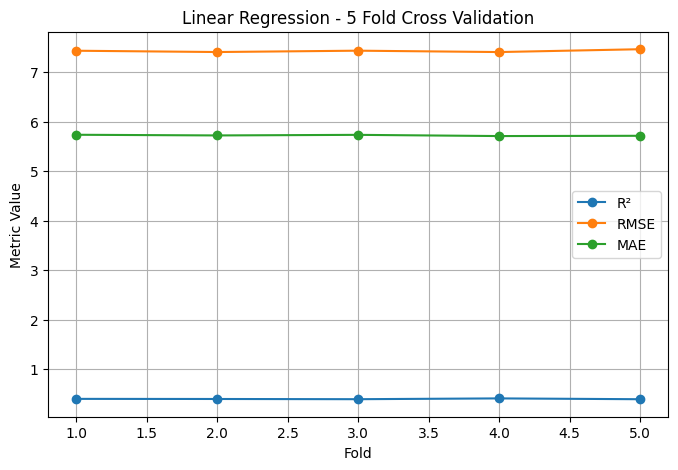

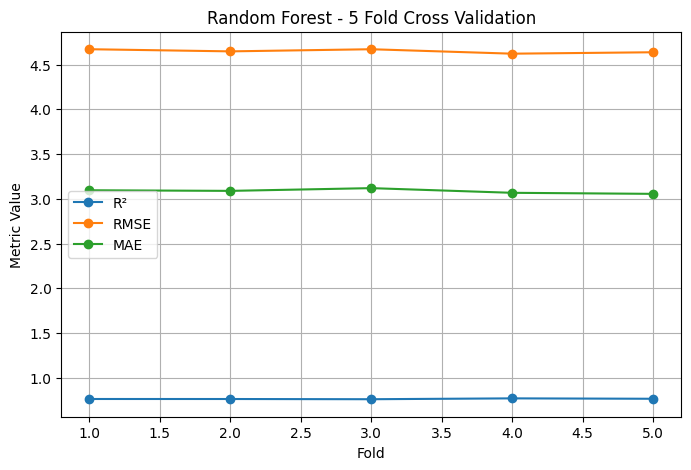

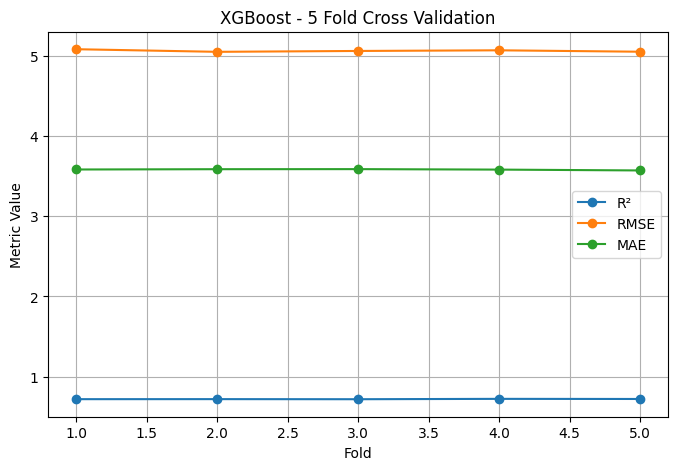


Final Model Comparison:
               Model    Avg R²    Avg MSE  Avg RMSE   Avg MAE
0  Linear Regression  0.401425  55.134191  7.425210  5.720950
1      Random Forest  0.765189  21.627672  4.650516  3.085821
2            XGBoost  0.722018  25.605423  5.060166  3.580755


In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_validate
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# -----------------------------
# Models
# -----------------------------

models = {
    "Linear Regression": LinearRegression(),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=42,
        n_jobs=1
    ),

    "XGBoost": XGBRegressor(
        n_estimators=100,
        learning_rate=0.1,
        random_state=42,
        n_jobs=1
    )
}

# -----------------------------
# 5 Fold Cross Validation
# -----------------------------

kf = KFold(
    n_splits=5,
    shuffle=True,
    random_state=42
)

scoring = {
    "r2": "r2",
    "mse": "neg_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

results = []
all_rmse_scores = {}

# -----------------------------
# Evaluate Models
# -----------------------------

for model_name, model in models.items():

    cv_results = cross_validate(
        model,
        X,
        y,
        cv=kf,
        scoring=scoring
    )

    r2_scores = cv_results['test_r2']

    mse_scores = -cv_results['test_mse']

    rmse_scores = np.sqrt(mse_scores)
    all_rmse_scores[model_name] = rmse_scores

    mae_scores = -cv_results['test_mae']

    results.append({
        "Model": model_name,

        "Avg R²": r2_scores.mean(),
        "Avg MSE": mse_scores.mean(),
        "Avg RMSE": rmse_scores.mean(),
        "Avg MAE": mae_scores.mean()
    })

    # -----------------------------
    # Graph for each model
    # -----------------------------

    folds = range(1, 6)

    plt.figure(figsize=(8,5))

    plt.plot(
        folds,
        r2_scores,
        marker='o',
        label='R²'
    )

    plt.plot(
        folds,
        rmse_scores,
        marker='o',
        label='RMSE'
    )

    plt.plot(
        folds,
        mae_scores,
        marker='o',
        label='MAE'
    )

    plt.xlabel("Fold")
    plt.ylabel("Metric Value")
    plt.title(f"{model_name} - 5 Fold Cross Validation")

    plt.legend()
    plt.grid(True)

    plt.show()

# -----------------------------
# Final Comparison Table
# -----------------------------

results_df = pd.DataFrame(results)

print("\nFinal Model Comparison:")
print(results_df)

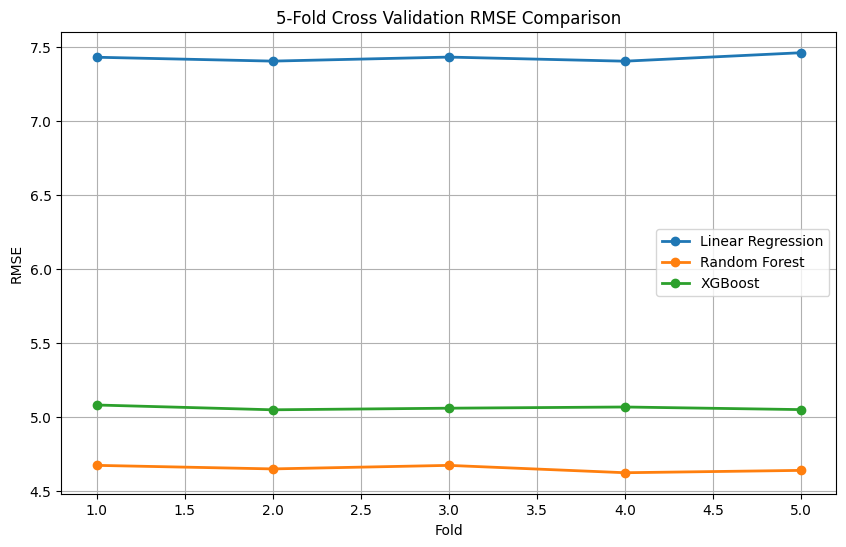

In [47]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

model_names = [
    'Linear Regression',
    'Random Forest',
    'XGBoost'
]

plt.figure(figsize=(10,6))

for name in model_names:
    rmse_scores = all_rmse_scores[name]
    plt.plot(
        range(1, 6),
        rmse_scores,
        marker='o',
        linewidth=2,
        label=name
    )

plt.xlabel("Fold")
plt.ylabel("RMSE")
plt.title("5-Fold Cross Validation RMSE Comparison")

plt.legend()
plt.grid(True)

plt.show()


In [48]:
# Train Random Forest
from sklearn.ensemble import RandomForestRegressor
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1)
rf_model.fit(X, y)

# Get feature importance
importance = rf_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': features,
    'Importance': importance
})
feature_importance_df = feature_importance_df.sort_values(
    by='Importance',
    ascending=False
)
print(feature_importance_df)


NameError: name 'rf_model' is not defined

# Advanced Assessment: Anomaly Detection, Spatial Analysis, and Model Ensembling

Below we implement the requested advanced sections: outlier analysis, global geographical trends, and a weighted ensemble model.

In [ ]:
# -----------------------------
# Anomaly Detection (Outliers)
# -----------------------------
# Identify extreme temperature anomalies using Z-score (> 3 standard deviations)
import numpy as np
import matplotlib.pyplot as plt

temp_mean = df['temperature_celsius'].mean()
temp_std = df['temperature_celsius'].std()

df['temp_z'] = (df['temperature_celsius'] - temp_mean) / temp_std
temp_anomalies = df[np.abs(df['temp_z']) > 3]

print(f"Total temperature records: {len(df)}")
print(f"Average Global Temp: {temp_mean:.2f}°C, Std Dev: {temp_std:.2f}")
print(f"Total temperature anomalies detected (Z-score > 3): {len(temp_anomalies)}")
print("Sample Anomalies (Extremes):")
print(temp_anomalies[['location_name', 'country', 'temperature_celsius', 'last_updated']].head(10))

plt.figure(figsize=(12, 6))
plt.scatter(df['last_updated'], df['temperature_celsius'], alpha=0.2, label='Normal Conditions', color='#3498db')
plt.scatter(temp_anomalies['last_updated'], temp_anomalies['temperature_celsius'], color='#e74c3c', label='Extreme Anomalies', alpha=0.8, s=25)
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Global Temperature Profile and Anomalies (Z-Score > 3)')
plt.legend()
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('visualizations/anomaly_detection_temp.png')
plt.savefig('../4_Report/visualizations/anomaly_detection_temp.png')
plt.show()


In [ ]:
# -----------------------------
# Spatial Analysis (Geographical Patterns)
# -----------------------------
# Visualizing global average temperature distributions across latitudes and longitudes
plt.figure(figsize=(14, 7))
sc = plt.scatter(df['longitude'], df['latitude'], c=df['temperature_celsius'], cmap='coolwarm', alpha=0.5, s=10)
plt.colorbar(sc, label='Temperature (°C)')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Global Spatial Temperature Distribution Map')
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('visualizations/spatial_temperature_map.png')
plt.savefig('../4_Report/visualizations/spatial_temperature_map.png')
plt.show()


In [ ]:
# -----------------------------
# Model Ensembling (Weighted Average)
# -----------------------------
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Train individual estimators on train partition
lr = LinearRegression()
rf = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=1)
xgb = XGBRegressor(n_estimators=100, learning_rate=0.1, random_state=42, n_jobs=1)

print("Training base estimators...")
lr.fit(X_train, y_train)
rf.fit(X_train, y_train)
xgb.fit(X_train, y_train)

lr_test_preds = lr.predict(X_test)
rf_test_preds = rf.predict(X_test)
xgb_test_preds = xgb.predict(X_test)

# Create weighted average ensemble prediction
# (40% RF, 40% XGBoost, 20% Linear Regression)
ensemble_preds = 0.4 * rf_test_preds + 0.4 * xgb_test_preds + 0.2 * lr_test_preds

# Collect metrics
models_comp = {
    "Linear Regression": lr_test_preds,
    "Random Forest": rf_test_preds,
    "XGBoost": xgb_test_preds,
    "Weighted Ensemble": ensemble_preds
}

comp_data = []
for name, preds in models_comp.items():
    comp_data.append({
        "Model": name,
        "MAE": mean_absolute_error(y_test, preds),
        "RMSE": np.sqrt(mean_squared_error(y_test, preds)),
        "R2 Score": r2_score(y_test, preds)
    })

comp_df = pd.DataFrame(comp_data)
print("\nFinal Model Comparison Table (Test Partition):")
print(comp_df.to_string(index=False))

# Plot comparison bar chart
plt.figure(figsize=(10, 5))
x = np.arange(len(comp_df))
plt.bar(x - 0.2, comp_df['MAE'], width=0.4, label='MAE', color='#34495e')
plt.bar(x + 0.2, comp_df['RMSE'], width=0.4, label='RMSE', color='#e67e22')
plt.xticks(x, comp_df['Model'])
plt.ylabel('Error Value (Lower is Better)')
plt.title('Regression Models Error Metrics Comparison')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.tight_layout()
plt.savefig('visualizations/model_comparison.png')
plt.savefig('../4_Report/visualizations/model_comparison.png')
plt.show()


In [ ]:
# -----------------------------
# Deep Time-Series Forecasting (PyTorch LSTM)
# -----------------------------
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
import numpy as np
import matplotlib.pyplot as plt

# Aggregate daily global average temperature
daily_temp = df.groupby('last_updated')['temperature_celsius'].mean().reset_index()
daily_temp = daily_temp.sort_values(by='last_updated').reset_index(drop=True)
temps = daily_temp['temperature_celsius'].values.reshape(-1, 1)

# Scale the features
scaler = StandardScaler()
scaled_temps = scaler.fit_transform(temps)

# Create sliding sequence windows of past 7 days to predict next day
def create_windows(input_data, tw):
    inout_seq = []
    L = len(input_data)
    for i in range(L-tw):
        train_seq = input_data[i:i+tw]
        train_label = input_data[i+tw:i+tw+1]
        inout_seq.append((train_seq, train_label))
    return inout_seq

window_size = 7
sequences = create_windows(scaled_temps, window_size)

# Train/Test Split (80% train, 20% test)
train_size = int(len(sequences) * 0.8)
train_seqs = sequences[:train_size]
test_seqs = sequences[train_size:]

def to_tensors(seqs):
    x = torch.stack([torch.FloatTensor(item[0]) for item in seqs])
    y = torch.stack([torch.FloatTensor(item[1]) for item in seqs]).view(-1, 1)
    return x, y

x_train, y_train = to_tensors(train_seqs)
x_test, y_test = to_tensors(test_seqs)

# LSTM Network Architecture
class TemperatureLSTM(nn.Module):
    def __init__(self, input_size=1, hidden_size=64, num_layers=1, output_size=1):
        super().__init__()
        self.lstm = nn.LSTM(input_size, hidden_size, num_layers, batch_first=True)
        self.linear = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        out, _ = self.lstm(x)
        out = self.linear(out[:, -1, :])
        return out

lstm_model = TemperatureLSTM()
loss_fn = nn.MSELoss()
opt = optim.Adam(lstm_model.parameters(), lr=0.01)

# Training Loop
epochs = 30
print("Training Deep Learning LSTM model for Time-Series forecasting...")
lstm_model.train()
for epoch in range(epochs):
    opt.zero_grad()
    preds = lstm_model(x_train)
    loss = loss_fn(preds, y_train)
    loss.backward()
    opt.step()

# Evaluation
lstm_model.eval()
with torch.no_grad():
    test_preds_scaled = lstm_model(x_test).numpy()

# Inverse scale back to actual temperature values
y_test_actual = scaler.inverse_transform(y_test.numpy())
y_test_pred = scaler.inverse_transform(test_preds_scaled)

# Calculate regression performance metrics
lstm_mae = np.mean(np.abs(y_test_actual - y_test_pred))
lstm_rmse = np.sqrt(np.mean((y_test_actual - y_test_pred)**2))
print(f"LSTM Test MAE: {lstm_mae:.2f}°C, RMSE: {lstm_rmse:.2f}°C")

# Plot Forecast vs Actual
plt.figure(figsize=(12, 6))
dates_test = daily_temp['last_updated'][train_size+window_size:]
plt.plot(dates_test, y_test_actual, label='Actual Temperatures', color='#2ecc71', linewidth=2)
plt.plot(dates_test, y_test_pred, label='LSTM 7-Day Window Forecast', color='#e74c3c', linestyle='--', linewidth=2)
plt.xlabel('Date')
plt.ylabel('Temperature (°C)')
plt.title('Global Temperature Time-Series Forecast (PyTorch LSTM Network)')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig('visualizations/lstm_timeseries_forecast.png')
plt.savefig('../4_Report/visualizations/lstm_timeseries_forecast.png')
plt.show()


In [ ]:
print("====================================================")
print("Product Manager Accelerator (PMA) AI Research Hub")
print("Mission: break down financial barriers and achieve educational fairness,")
print("empowering professionals to become AI product leaders.")
print("Data Science Weather Forecasting Report successfully compiled.")
print("====================================================")
